# Shifted Exponential Fill Model — Quick Check

Fits `λ(δ) = A_liq × exp(-κ × δ) + A_mom` and compares against pure exponential.
Uses AIC for formal model selection.

**Run kappa_analysis.ipynb first** — this notebook reuses `merged_all`, `fp_A`, `fp_B`,
`roll_B`, `good_B`, `trades`, `quotes` from that session.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from pathlib import Path
import sys
import warnings
from hft_market_maker.core.fill_analysis import (
    load_day,
    compute_fill_curve,
    empirical_fill_prob,
    fit_exponential,
    simulate_fill_curve,
    fit_shifted_exponential,
    shifted_exponential,
    compare_fits,
    rolling_fit,
)
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from hft_market_maker.strategies.glft import GLFTMarketMaker

# ── import shifted model ───────────────────────────────────────────
# copy shifted_glft.py into hft_market_maker/strategies/ first
# then: from hft_market_maker.strategies.shifted_glft import ...
# For now load directly
import importlib.util, pathlib
spec = importlib.util.spec_from_file_location(
    'shifted_glft',
    ROOT / 'hft_market_maker' / 'strategies' / 'shifted_glft.py'
)
sg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sg)
fit_shifted_exponential = sg.fit_shifted_exponential
compare_fits             = sg.compare_fits
shifted_exponential      = sg.shifted_exponential
ShiftedGLFTMarketMaker   = sg.ShiftedGLFTMarketMaker

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
TICK = 0.01
print('Setup complete')

Setup complete


In [13]:
TICK            = 0.01
MAX_DELTA_TICKS = 10
MAX_QUOTE_AGE   = 200
LATENCY         = 0.10
QUOTE_INTERVAL  = 0.50
MIN_TRADES      = 200
ROLL_WINDOW     = 15
ROLL_STEP       = 5
DATE            = '2025-05-13'
DATA_DIR        = Path('../data/real')

# Load data
trades, quotes = load_day(DATE,DATA_DIR)
print(f'Trades: {len(trades):,}  |  Quotes: {len(quotes):,}')

# Approach A — market trade curve
merged_all = compute_fill_curve(trades, quotes)
fp_A = empirical_fill_prob(merged_all)
A_hat, kappa_hat, se_A, se_kappa, r2 = fit_exponential(fp_A, min_delta=0.5)

# Approach B — execution simulation (takes ~1-2 min)
print('Running Approach B simulation...')
fp_B = simulate_fill_curve(trades, quotes, verbose=True)
A_B, kappa_B, se_A_B, se_kappa_B, r2_B = fit_exponential(fp_B, min_delta=0.5)

print(f'\nApproach A: kappa={kappa_hat:.4f}  R2={r2:.4f}')
print(f'Approach B: kappa={kappa_B:.4f}')

Trades: 3,476,024  |  Quotes: 681,990
Running Approach B simulation...
  delta=0.5 ticks: fill_rate=0.6916
  delta=1.5 ticks: fill_rate=0.1540
  delta=2.5 ticks: fill_rate=0.1522
  delta=3.5 ticks: fill_rate=0.1519
  delta=4.5 ticks: fill_rate=0.1517
  delta=5.5 ticks: fill_rate=0.1516
  delta=6.5 ticks: fill_rate=0.1515
  delta=7.5 ticks: fill_rate=0.1514
  delta=8.5 ticks: fill_rate=0.1513
  delta=9.5 ticks: fill_rate=0.1513

Approach A: kappa=0.0654  R2=0.3769
Approach B: kappa=0.3113


## 1. Full-Day Fit Comparison — Pure vs Shifted Exponential

In [ ]:
def compute_fill_curve(trades, quotes,
                       max_quote_age_ms=MAX_QUOTE_AGE):
    """
    Merge mid + sigma onto each trade, compute distance from mid in ticks.
    Drops trades where mid is stale. Returns merged DataFrame.
    """
    q = quotes.copy()
    q['log_ret']          = np.log(q['mid']).diff()
    dt_sec                = q['ts'].diff().dt.total_seconds().clip(lower=1e-6)
    q['ret_per_sqrt_sec'] = q['log_ret'] / np.sqrt(dt_sec)
    q['sigma']            = q['ret_per_sqrt_sec'].rolling(200, min_periods=10).std()
    q['sigma_dollar']     = q['sigma'] * q['mid']

    merged = pd.merge_asof(
        trades[['ts', 'price', 'size']].sort_values('ts'),
        q[['ts', 'mid', 'sigma', 'sigma_dollar']].sort_values('ts')
          .rename(columns={'ts': 'quote_ts'}),
        left_on='ts', right_on='quote_ts', direction='backward'
    )
    merged = merged.dropna(subset=['mid', 'sigma_dollar'])
    merged['quote_age_ms'] = (
        merged['ts'] - merged['quote_ts']
    ).dt.total_seconds() * 1000
    merged = merged[merged['quote_age_ms'] < max_quote_age_ms]
    merged['delta_dollar'] = np.abs(merged['price'] - merged['mid'])
    merged['delta']        = merged['delta_dollar'] / TICK
    merged['hour']         = merged['ts'].dt.hour
    merged = merged[merged['delta'] > 0]
    return merged


def empirical_fill_prob(merged_all, max_delta_ticks=MAX_DELTA_TICKS):
    """P(fill | delta >= bin) using half-tick bins 0.5, 1.5, 2.5 ..."""
    all_deltas = merged_all['delta'].values
    bins = np.arange(0.5, max_delta_ticks + 0.5, 1.0)
    probs = [(b, (all_deltas >= b).mean()) for b in bins]
    df = pd.DataFrame(probs, columns=['delta', 'fill_prob'])
    return df[df['fill_prob'] > 0].reset_index(drop=True)


def fit_exponential(fp_df, min_delta=0.5):
    """
    Fit A * exp(-kappa * delta). min_delta controls which points to include.
    Returns (A, kappa, se_A, se_kappa, r2) or all None on failure.
    """
    df = fp_df[fp_df['delta'] >= min_delta].copy()
    if len(df) < 3:
        return None, None, None, None, None

    def model(delta, A, kappa):
        return A * np.exp(-kappa * delta)

    try:
        p0 = [df['fill_prob'].iloc[0], 0.5]
        popt, pcov = curve_fit(
            model, df['delta'].values, df['fill_prob'].values,
            p0=p0, bounds=([0, 1e-4], [5, 200]), maxfev=10000
        )
        A_hat, kappa_hat = popt
        se = np.sqrt(np.diag(pcov))
        y      = df['fill_prob'].values
        y_hat  = model(df['delta'].values, A_hat, kappa_hat)
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
        return A_hat, kappa_hat, se[0], se[1], r2
    except Exception:
        return None, None, None, None, None


# ── Approach B ─────────────────────────────────────────────────────

def simulate_order_fills(trades, quotes,
                          half_spread_ticks,
                          latency=LATENCY,
                          quote_interval=QUOTE_INTERVAL,
                          max_quote_age_ms=MAX_QUOTE_AGE):
    """
    Simulate placing limit orders at half_spread_ticks from mid at every
    quote_interval with given latency. Exposure window = quote_interval seconds
    (cancel latency extends it by exactly as much as activation latency delays it).

    Returns (fill_rate, results_df).
    """
    half_spread = half_spread_ticks * TICK

    trades_ts  = (trades['ts'].astype(np.int64) / 1e9).values
    trades_px  = trades['price'].values
    quotes_ts  = (quotes['ts'].astype(np.int64) / 1e9).values
    quotes_mid = quotes['mid'].values

    t_min = trades_ts[0]
    t_max = trades_ts[-1]

    results = []
    t = t_min

    while t < t_max - quote_interval:
        # Most recent quote before t
        q_idx = np.searchsorted(quotes_ts, t, side='right') - 1
        if q_idx < 0:
            t += quote_interval
            continue

        # Drop stale quotes
        quote_age_ms = (t - quotes_ts[q_idx]) * 1000
        if quote_age_ms > max_quote_age_ms:
            t += quote_interval
            continue

        mid = quotes_mid[q_idx]
        bid = mid - half_spread
        ask = mid + half_spread

        # Exposure: [t+latency, t+quote_interval+latency]
        active_from = t + latency
        active_to   = t + quote_interval + latency

        lo = np.searchsorted(trades_ts, active_from, side='left')
        hi = np.searchsorted(trades_ts, active_to,   side='right')
        window_px = trades_px[lo:hi]

        bid_filled = bool(np.any(window_px <= bid))
        ask_filled = bool(np.any(window_px >= ask))

        results.append({
            'ts':         t,
            'mid':        mid,
            'bid_filled': bid_filled,
            'ask_filled': ask_filled,
            'any_filled': bid_filled or ask_filled,
            'n_window':   len(window_px),
        })
        t += quote_interval

    df = pd.DataFrame(results)
    fill_rate = df['any_filled'].mean() if len(df) > 0 else 0.0
    return fill_rate, df


def simulate_fill_curve(trades, quotes,
                         deltas=None,
                         latency=LATENCY,
                         quote_interval=QUOTE_INTERVAL,
                         verbose=True):
    """Sweep spread distances and return fill rate DataFrame."""
    if deltas is None:
        deltas = np.arange(0.5, MAX_DELTA_TICKS + 0.5, 1.0)
    rows = []
    for d in deltas:
        rate, _ = simulate_order_fills(
            trades, quotes, half_spread_ticks=d,
            latency=latency, quote_interval=quote_interval
        )
        rows.append({'delta': d, 'fill_prob': rate})
        if verbose:
            print(f'  delta={d:.1f} ticks: fill_rate={rate:.4f}')
    return pd.DataFrame(rows)

In [14]:
# Recompute fp_B if not available from kappa_analysis session
try:
    fp_B
    print(f'fp_B already in session — {len(fp_B)} points')
except NameError:
    print('fp_B not found — recomputing...')
    
    # Need merged_all too
    try:
        merged_all
    except NameError:
        merged_all = compute_fill_curve(trades, quotes)
        print(f'merged_all recomputed: {len(merged_all):,} trades')
    
    fp_B = simulate_fill_curve(
        trades, quotes,
        deltas=np.arange(0.5, MAX_DELTA_TICKS + 0.5, 1.0),
        verbose=True
    )
    print(f'fp_B recomputed: {len(fp_B)} points')

print(fp_B)

fp_B already in session — 10 points
   delta  fill_prob
0    0.5   0.691617
1    1.5   0.153997
2    2.5   0.152239
3    3.5   0.151875
4    4.5   0.151733
5    5.5   0.151642
6    6.5   0.151544
7    7.5   0.151421
8    8.5   0.151330
9    9.5   0.151285


In [15]:
# Fit both models to full-day Approach B curve
comp = compare_fits(fp_B, min_delta=0.5)

exp_r  = comp['exponential']
sh_r   = comp['shifted']

print('Full-day fit comparison (Approach B):')
print(f'  Pure exponential:     A={exp_r["A"]:.4f}  kappa={exp_r["kappa"]:.4f}  '
      f'R2={exp_r["r2"]:.4f}  AIC={exp_r["aic"]:.2f}')
print(f'  Shifted exponential:  A_liq={sh_r["A_liq"]:.4f}  kappa={sh_r["kappa"]:.4f}  '
      f'A_mom={sh_r["A_floor"]:.4f}  R2={sh_r["r2"]:.4f}  AIC={sh_r["aic"]:.2f}')
print(f'  Delta AIC (exp - shifted): {comp["delta_aic"]:.2f}  '
      f'(>2 favours shifted)')
print(f'  Preferred model: {comp["preferred"]}')
print()
print(f'  Momentum fraction: {sh_r["mom_fraction"]*100:.1f}% of fills inevitably adverse')
print(f'  A_total = {sh_r["A_total"]:.4f}  (A_liq + A_mom)')

Full-day fit comparison (Approach B):
  Pure exponential:     A=0.5880  kappa=0.3113  R2=0.4637  AIC=-38.64
  Shifted exponential:  A_liq=5.0000  kappa=4.4502  A_mom=0.1512  R2=0.9999  AIC=-128.50
  Delta AIC (exp - shifted): 89.86  (>2 favours shifted)
  Preferred model: shifted

  Momentum fraction: 2.9% of fills inevitably adverse
  A_total = 5.1512  (A_liq + A_mom)


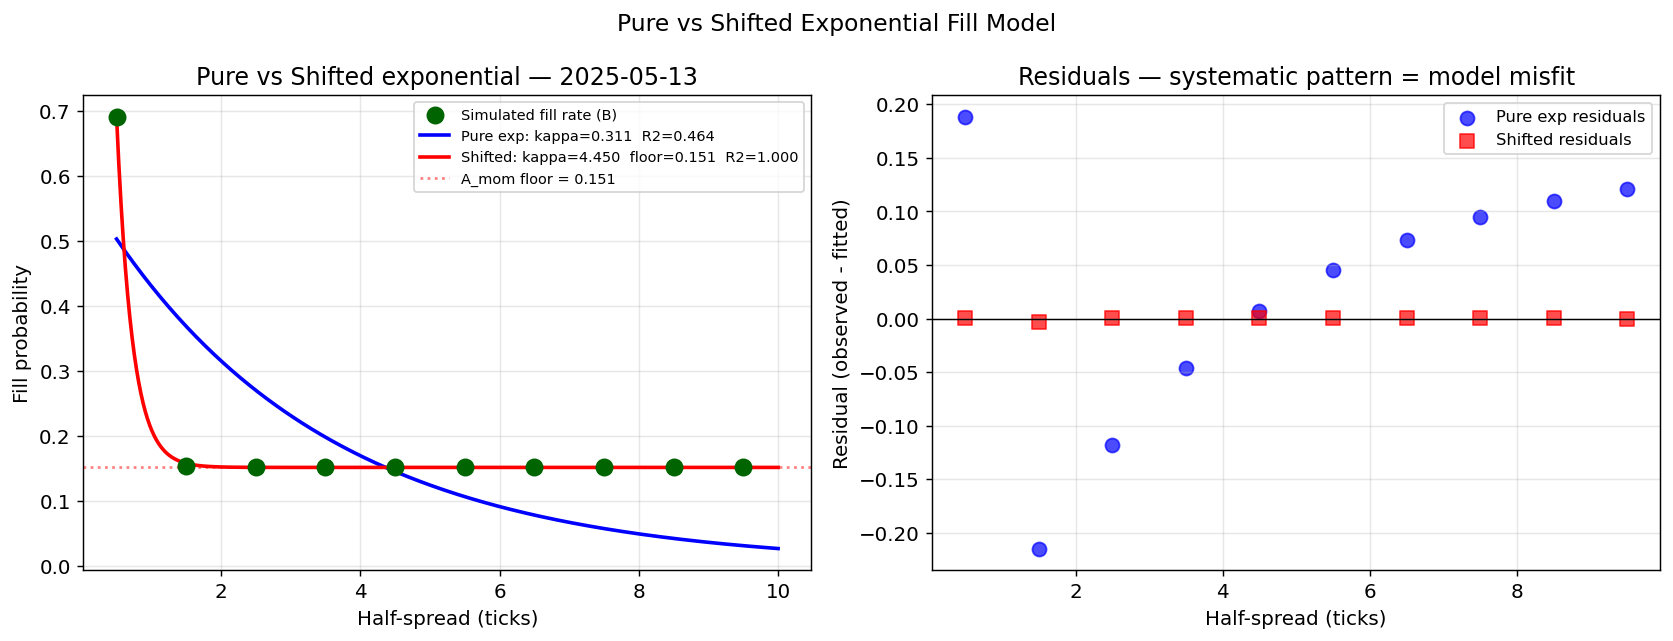

In [16]:
delta_range = np.linspace(0.5, 10, 300)
fitted_exp  = exp_r['A'] * np.exp(-exp_r['kappa'] * delta_range)
fitted_sh   = shifted_exponential(delta_range, sh_r['A_liq'], sh_r['kappa'], sh_r['A_floor'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
axes[0].scatter(fp_B['delta'], fp_B['fill_prob'], s=80, zorder=4,
                color='darkgreen', label='Simulated fill rate (B)')
axes[0].plot(delta_range, fitted_exp, 'b-', lw=2,
             label=f'Pure exp: kappa={exp_r["kappa"]:.3f}  R2={exp_r["r2"]:.3f}')
axes[0].plot(delta_range, fitted_sh, 'r-', lw=2,
             label=f'Shifted: kappa={sh_r["kappa"]:.3f}  floor={sh_r["A_floor"]:.3f}  R2={sh_r["r2"]:.3f}')
axes[0].axhline(sh_r['A_floor'], color='red', ls=':', alpha=0.5,
                label=f'A_mom floor = {sh_r["A_floor"]:.3f}')
axes[0].set_xlabel('Half-spread (ticks)')
axes[0].set_ylabel('Fill probability')
axes[0].set_title(f'Pure vs Shifted exponential — {DATE}')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Residuals
y_obs  = fp_B['fill_prob'].values
x_obs  = fp_B['delta'].values
res_exp = y_obs - exp_r['A'] * np.exp(-exp_r['kappa'] * x_obs)
res_sh  = y_obs - shifted_exponential(x_obs, sh_r['A_liq'], sh_r['kappa'], sh_r['A_floor'])

axes[1].axhline(0, color='black', lw=0.8)
axes[1].scatter(x_obs, res_exp, s=60, color='blue', alpha=0.7, label='Pure exp residuals')
axes[1].scatter(x_obs, res_sh,  s=60, color='red',  alpha=0.7, marker='s', label='Shifted residuals')
axes[1].set_xlabel('Half-spread (ticks)')
axes[1].set_ylabel('Residual (observed - fitted)')
axes[1].set_title('Residuals — systematic pattern = model misfit')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Pure vs Shifted Exponential Fill Model', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/shifted_fit_fullday_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Rolling Fit — Does the Floor Vary Over Time?

In [17]:
# Refit shifted model on each rolling window from roll_B
# roll_B already has the simulated fill curves per window
# We need to rerun simulate_fill_curve per window and fit shifted model

print('Computing shifted exponential fit on rolling windows...')
print('(Reuses windows from roll_B — only adds shifted fit on top)')
print()

# Re-run rolling with shifted fit
ROLL_WINDOW = 15
ROLL_STEP   = 5
LATENCY     = 0.1
QUOTE_INTERVAL = 0.5
MIN_TRADES  = 200
MAX_DELTA_TICKS = 10

roll_shifted = []
t_min = trades['ts'].min()
t_max = trades['ts'].max()
window = pd.Timedelta(minutes=ROLL_WINDOW)
step   = pd.Timedelta(minutes=ROLL_STEP)
t = t_min

while t + window <= t_max:
    t_end = t + window
    sub_t = trades[(trades['ts'] >= t) & (trades['ts'] < t_end)]
    sub_q = quotes[
        (quotes['ts'] >= t - pd.Timedelta(seconds=5)) &
        (quotes['ts'] < t_end + pd.Timedelta(seconds=5))
    ]

    if len(sub_t) >= MIN_TRADES and len(sub_q) >= 10:
        # Simulate fill curve for this window
        deltas = np.arange(0.5, MAX_DELTA_TICKS + 0.5, 1.0)
        rows = []
        trades_ts  = (sub_t['ts'].astype(np.int64) / 1e9).values
        trades_px  = sub_t['price'].values
        quotes_ts  = (sub_q['ts'].astype(np.int64) / 1e9).values
        quotes_mid = sub_q['mid'].values

        for d in deltas:
            hs = d * TICK
            tt = trades_ts[0]
            fills = 0; total = 0
            while tt < trades_ts[-1] - QUOTE_INTERVAL:
                q_idx = np.searchsorted(quotes_ts, tt, side='right') - 1
                if q_idx >= 0:
                    mid = quotes_mid[q_idx]
                    af  = tt + LATENCY
                    at  = tt + QUOTE_INTERVAL + LATENCY
                    lo  = np.searchsorted(trades_ts, af, side='left')
                    hi  = np.searchsorted(trades_ts, at, side='right')
                    wp  = trades_px[lo:hi]
                    if len(wp) > 0:
                        fills += int(np.any(wp <= mid - hs) or np.any(wp >= mid + hs))
                    total += 1
                tt += QUOTE_INTERVAL
            rows.append({'delta': d, 'fill_prob': fills / total if total > 0 else 0.0})

        fp_w = pd.DataFrame(rows)

        # Fit both models
        comp_w = compare_fits(fp_w, min_delta=0.5)
        sh_w   = comp_w.get('shifted')
        ex_w   = comp_w.get('exponential')

        sub_m = merged_all[(merged_all['ts'] >= t) & (merged_all['ts'] < t_end)]
        sigma_d = sub_m['sigma_dollar'].mean() if len(sub_m) > 0 else np.nan

        row = {
            'window_mid':   t + window / 2,
            'sigma_dollar': sigma_d,
            'r2_exp':       ex_w['r2']     if ex_w else np.nan,
            'r2_sh':        sh_w['r2']     if sh_w else np.nan,
            'kappa_exp':    ex_w['kappa']  if ex_w else np.nan,
            'kappa_sh':     sh_w['kappa']  if sh_w else np.nan,
            'A_liq':        sh_w['A_liq']  if sh_w else np.nan,
            'A_mom':        sh_w['A_floor']if sh_w else np.nan,
            'A_total':      sh_w['A_total']if sh_w else np.nan,
            'mom_frac':     sh_w['mom_fraction'] if sh_w else np.nan,
            'delta_aic':    comp_w['delta_aic'],
            'preferred':    comp_w['preferred'],
        }
        roll_shifted.append(row)
        print(f'  {(t+window/2).strftime("%H:%M")}  '
              f'kappa_sh={sh_w["kappa"]:.3f}  '
              f'A_mom={sh_w["A_floor"]:.3f}  '
              f'mom%={sh_w["mom_fraction"]*100:.0f}%  '
              f'R2_sh={sh_w["r2"]:.3f}  '
              f'DAIC={comp_w["delta_aic"]:+.1f}  '
              f'pref={comp_w["preferred"]}'
              if sh_w else f'  {(t+window/2).strftime("%H:%M")}  fit failed')

    t += step

rsh = pd.DataFrame(roll_shifted)
rsh['window_mid'] = pd.to_datetime(rsh['window_mid'])
rsh['hour'] = rsh['window_mid'].dt.hour
print(f'\nWindows computed: {len(rsh)}')
print(f'Shifted preferred in {(rsh["preferred"]=="shifted").mean()*100:.0f}% of windows')
print(f'Momentum fraction — mean={rsh["mom_frac"].mean():.3f}  std={rsh["mom_frac"].std():.3f}')

Computing shifted exponential fit on rolling windows...
(Reuses windows from roll_B — only adds shifted fit on top)

  00:07  kappa_sh=4.272  A_mom=0.114  mom%=2%  R2_sh=1.000  DAIC=+80.1  pref=shifted
  00:12  kappa_sh=4.471  A_mom=0.147  mom%=3%  R2_sh=1.000  DAIC=+87.6  pref=shifted
  00:17  kappa_sh=4.337  A_mom=0.143  mom%=3%  R2_sh=1.000  DAIC=+102.1  pref=shifted
  00:22  kappa_sh=4.685  A_mom=0.159  mom%=3%  R2_sh=1.000  DAIC=+99.0  pref=shifted
  00:27  kappa_sh=4.685  A_mom=0.161  mom%=3%  R2_sh=1.000  DAIC=+114.3  pref=shifted
  00:32  kappa_sh=4.443  A_mom=0.167  mom%=3%  R2_sh=1.000  DAIC=+90.0  pref=shifted
  00:37  kappa_sh=4.422  A_mom=0.153  mom%=3%  R2_sh=1.000  DAIC=+91.7  pref=shifted
  00:42  kappa_sh=4.284  A_mom=0.157  mom%=3%  R2_sh=1.000  DAIC=+92.8  pref=shifted
  00:47  kappa_sh=4.511  A_mom=0.173  mom%=3%  R2_sh=1.000  DAIC=+97.6  pref=shifted
  00:52  kappa_sh=4.544  A_mom=0.137  mom%=3%  R2_sh=1.000  DAIC=+98.0  pref=shifted
  00:57  kappa_sh=4.516  A_mom=

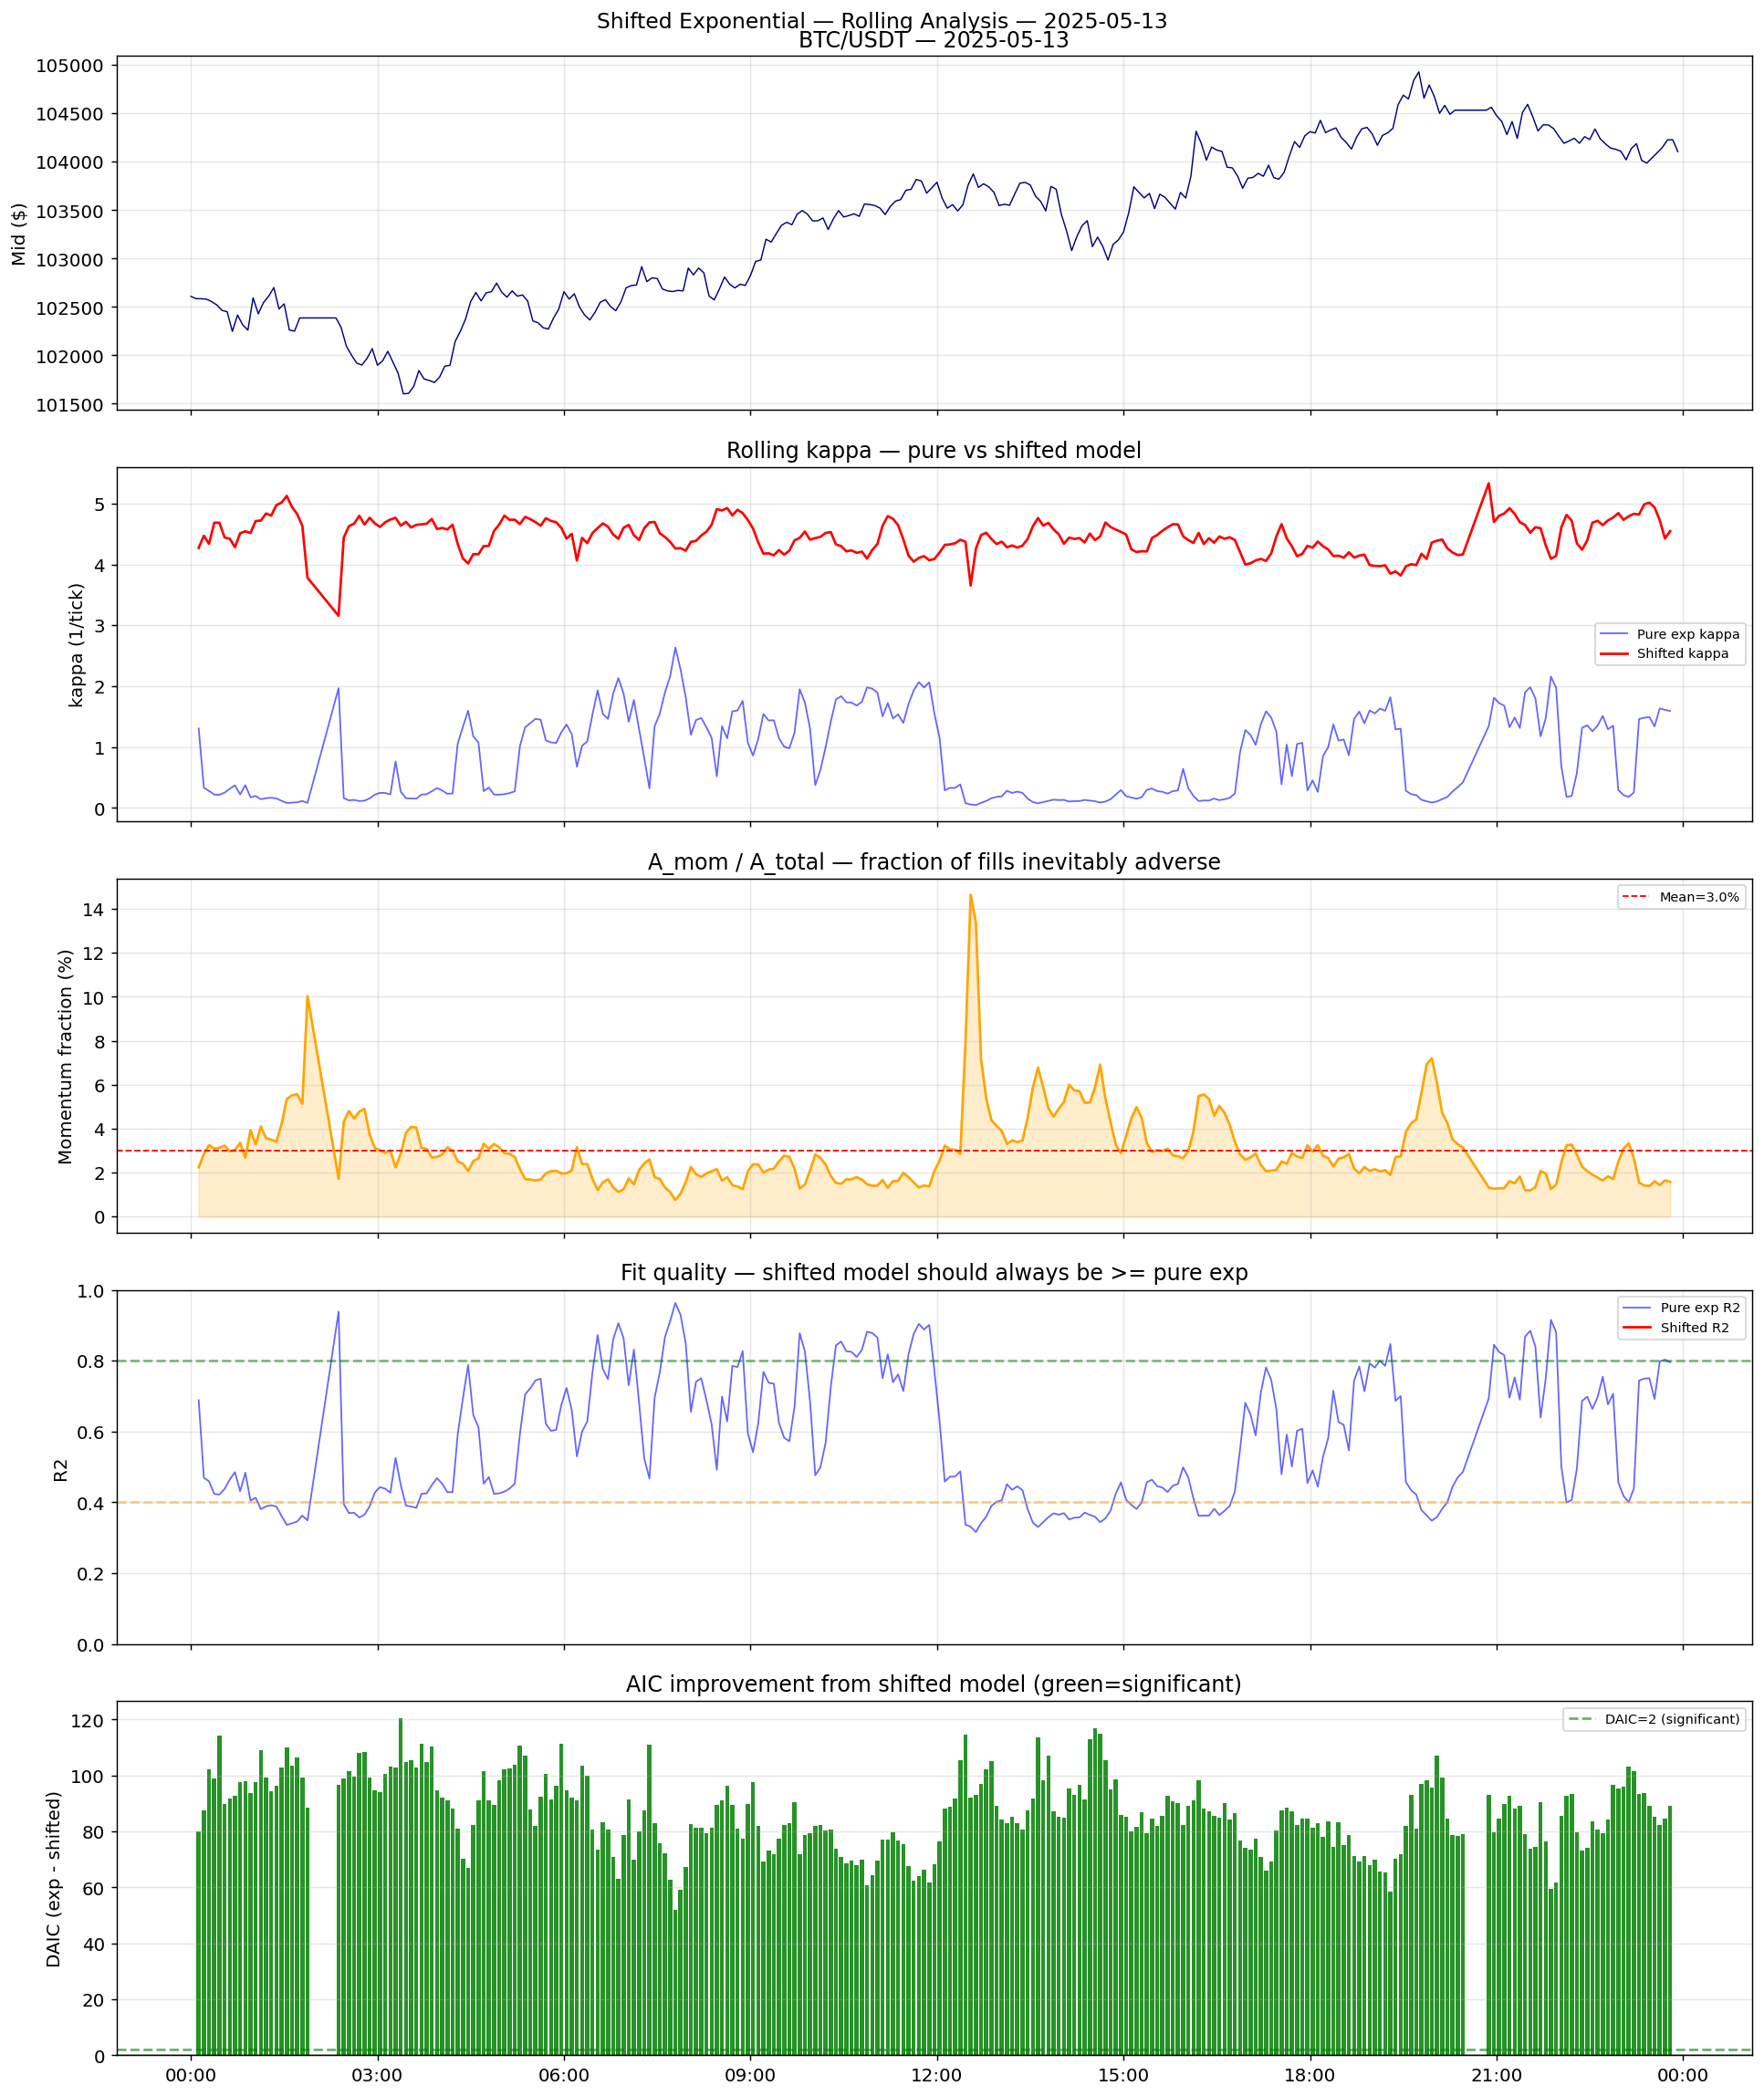

In [18]:
mid_resampled = quotes.set_index('ts')['mid'].resample('5min').last().ffill()
fmt = mdates.DateFormatter('%H:%M')

fig, axes = plt.subplots(5, 1, figsize=(15, 18), sharex=True)
ts = rsh['window_mid']

# Price
axes[0].plot(mid_resampled.index, mid_resampled.values, lw=0.8, color='navy')
axes[0].set_ylabel('Mid ($)'); axes[0].set_title(f'BTC/USDT — {DATE}'); axes[0].grid(alpha=0.3)

# kappa — pure vs shifted
axes[1].plot(ts, rsh['kappa_exp'], lw=1, color='blue', alpha=0.6, label='Pure exp kappa')
axes[1].plot(ts, rsh['kappa_sh'],  lw=1.5, color='red', label='Shifted kappa')
axes[1].set_ylabel('kappa (1/tick)')
axes[1].set_title('Rolling kappa — pure vs shifted model')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Momentum fraction
axes[2].plot(ts, rsh['mom_frac'] * 100, lw=1.5, color='orange')
axes[2].fill_between(ts, 0, rsh['mom_frac'] * 100, alpha=0.2, color='orange')
axes[2].axhline(rsh['mom_frac'].mean() * 100, color='red', ls='--', lw=1,
                label=f'Mean={rsh["mom_frac"].mean()*100:.1f}%')
axes[2].set_ylabel('Momentum fraction (%)')
axes[2].set_title('A_mom / A_total — fraction of fills inevitably adverse')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

# R2 comparison
axes[3].plot(ts, rsh['r2_exp'], lw=1, color='blue', alpha=0.6, label='Pure exp R2')
axes[3].plot(ts, rsh['r2_sh'],  lw=1.5, color='red', label='Shifted R2')
axes[3].axhline(0.8, color='green', ls='--', alpha=0.5)
axes[3].axhline(0.4, color='orange', ls='--', alpha=0.5)
axes[3].set_ylim(0, 1); axes[3].set_ylabel('R2')
axes[3].set_title('Fit quality — shifted model should always be >= pure exp')
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

# Delta AIC — positive means shifted is better
daic_colors = ['green' if d > 2 else 'orange' if d > 0 else 'red' for d in rsh['delta_aic']]
axes[4].bar(ts, rsh['delta_aic'], width=pd.Timedelta(minutes=4),
             color=daic_colors, alpha=0.85, edgecolor='none')
axes[4].axhline(2, color='green', ls='--', alpha=0.6, label='DAIC=2 (significant)')
axes[4].axhline(0, color='black', lw=0.8)
axes[4].set_ylabel('DAIC (exp - shifted)')
axes[4].set_title('AIC improvement from shifted model (green=significant)')
axes[4].legend(fontsize=8); axes[4].grid(alpha=0.3, axis='y')
axes[4].xaxis.set_major_formatter(fmt)

plt.suptitle(f'Shifted Exponential — Rolling Analysis — {DATE}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/shifted_rolling_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Good Windows — Shifted vs Pure Fit

In [19]:
# Find best shifted windows by R2
good_sh = rsh[rsh['r2_sh'] > 0.8].copy()
print(f'Windows with R2_shifted > 0.8: {len(good_sh)}/{len(rsh)}')
print(f'kappa_sh mean={good_sh["kappa_sh"].mean():.4f}  std={good_sh["kappa_sh"].std():.4f}')
print(f'A_mom    mean={good_sh["A_mom"].mean():.4f}  std={good_sh["A_mom"].std():.4f}')
print(f'mom_frac mean={good_sh["mom_frac"].mean()*100:.1f}%')
print()
print('By hour:')
print(good_sh.groupby('hour')[['kappa_sh', 'A_mom', 'mom_frac', 'r2_sh']]
      .mean().round(4).to_string())

Windows with R2_shifted > 0.8: 276/276
kappa_sh mean=4.4550  std=0.2787
A_mom    mean=0.1503  std=0.0746
mom_frac mean=3.0%

By hour:
      kappa_sh   A_mom  mom_frac   r2_sh
hour                                    
0       4.4699  0.1541    0.0307  1.0000
1       4.7615  0.2322    0.0488  1.0000
2       4.4736  0.1961    0.0398  1.0000
3       4.6716  0.1616    0.0313  1.0000
4       4.3683  0.1458    0.0283  0.9999
5       4.7128  0.1071    0.0211  1.0000
6       4.4744  0.0893    0.0182  0.9999
7       4.4665  0.0833    0.0164  0.9999
8       4.7012  0.0920    0.0181  0.9999
9       4.3215  0.1111    0.0217  0.9999
10      4.3113  0.0954    0.0187  0.9999
11      4.3468  0.0810    0.0159  0.9999
12      4.3026  0.2548    0.0598  1.0000
13      4.4789  0.2406    0.0458  0.9999
14      4.4807  0.2629    0.0514  1.0000
15      4.4359  0.1778    0.0343  0.9999
16      4.3598  0.2205    0.0421  0.9999
17      4.2393  0.1310    0.0255  0.9999
18      4.1827  0.1307    0.0255  0.9999
19   

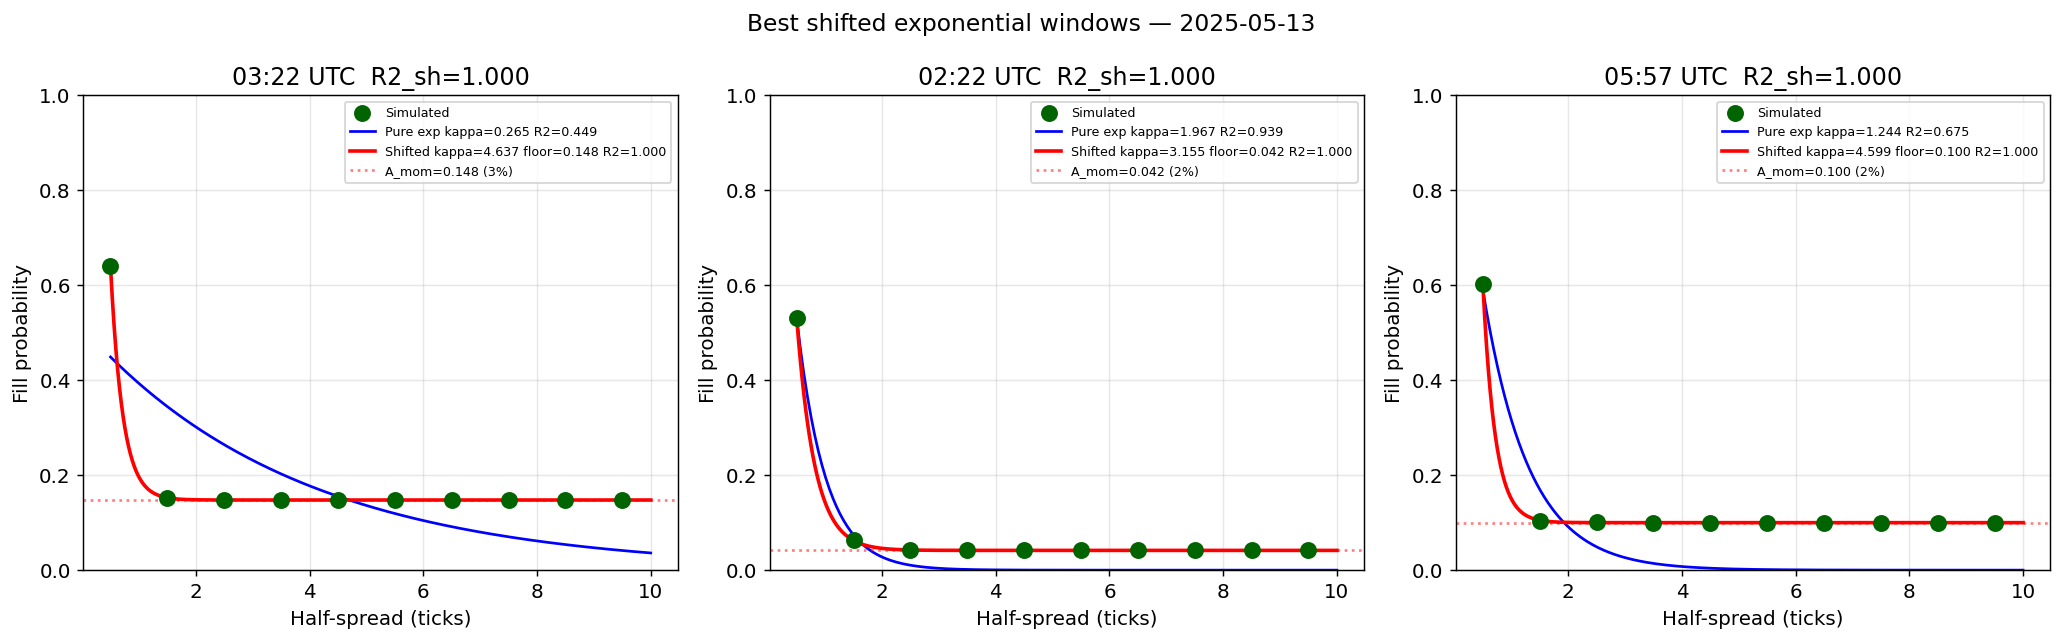

In [20]:
# Plot fill curves for 3 representative good windows
if len(good_sh) >= 3:
    sample_windows = good_sh.nlargest(3, 'r2_sh')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    delta_range = np.linspace(0.5, MAX_DELTA_TICKS, 300)

    for ax, (_, row) in zip(axes, sample_windows.iterrows()):
        t_start = row['window_mid'] - pd.Timedelta(minutes=ROLL_WINDOW/2)
        t_end   = row['window_mid'] + pd.Timedelta(minutes=ROLL_WINDOW/2)
        sub_t = trades[(trades['ts'] >= t_start) & (trades['ts'] < t_end)]
        sub_q = quotes[
            (quotes['ts'] >= t_start - pd.Timedelta(seconds=5)) &
            (quotes['ts'] < t_end + pd.Timedelta(seconds=5))
        ]

        # Recompute fill curve for this window
        deltas = np.arange(0.5, MAX_DELTA_TICKS + 0.5, 1.0)
        fp_rows = []
        if len(sub_t) > 0 and len(sub_q) > 0:
            ts_arr = (sub_t['ts'].astype(np.int64)/1e9).values
            px_arr = sub_t['price'].values
            qt_arr = (sub_q['ts'].astype(np.int64)/1e9).values
            qm_arr = sub_q['mid'].values
            for d in deltas:
                hs = d * TICK
                tt = ts_arr[0]; fills=0; total=0
                while tt < ts_arr[-1] - QUOTE_INTERVAL:
                    qi = np.searchsorted(qt_arr, tt, side='right') - 1
                    if qi >= 0:
                        mid = qm_arr[qi]
                        lo = np.searchsorted(ts_arr, tt+LATENCY, side='left')
                        hi = np.searchsorted(ts_arr, tt+QUOTE_INTERVAL+LATENCY, side='right')
                        wp = px_arr[lo:hi]
                        if len(wp)>0:
                            fills += int(np.any(wp<=mid-hs) or np.any(wp>=mid+hs))
                        total += 1
                    tt += QUOTE_INTERVAL
                fp_rows.append({'delta': d, 'fill_prob': fills/total if total>0 else 0})
        fp_w = pd.DataFrame(fp_rows)

        comp_w = compare_fits(fp_w, min_delta=0.5)
        sh_w   = comp_w['shifted']
        ex_w   = comp_w['exponential']

        ax.scatter(fp_w['delta'], fp_w['fill_prob'], s=70, zorder=4,
                   color='darkgreen', label='Simulated')
        if ex_w:
            ax.plot(delta_range, ex_w['A']*np.exp(-ex_w['kappa']*delta_range),
                    'b-', lw=1.5, label=f'Pure exp kappa={ex_w["kappa"]:.3f} R2={ex_w["r2"]:.3f}')
        if sh_w:
            ax.plot(delta_range,
                    shifted_exponential(delta_range, sh_w['A_liq'], sh_w['kappa'], sh_w['A_floor']),
                    'r-', lw=2,
                    label=f'Shifted kappa={sh_w["kappa"]:.3f} floor={sh_w["A_floor"]:.3f} R2={sh_w["r2"]:.3f}')
            ax.axhline(sh_w['A_floor'], color='red', ls=':', alpha=0.5,
                       label=f'A_mom={sh_w["A_floor"]:.3f} ({sh_w["mom_fraction"]*100:.0f}%)')

        hour_str = row['window_mid'].strftime('%H:%M')
        ax.set_title(f'{hour_str} UTC  R2_sh={row["r2_sh"]:.3f}')
        ax.set_xlabel('Half-spread (ticks)')
        ax.set_ylabel('Fill probability')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.suptitle(f'Best shifted exponential windows — {DATE}', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'../analysis/shifted_good_windows_{DATE}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. GLFT vs ShiftedGLFT — Implied Spread Comparison

In [21]:
mid_price = quotes['mid'].median()
sigma_est = merged_all['sigma_dollar'].median() / mid_price

# Use high-quality shifted parameters
A_liq_use = good_sh['A_liq'].mean() if len(good_sh) > 0 else sh_r['A_liq']
A_mom_use = good_sh['A_mom'].mean() if len(good_sh) > 0 else sh_r['A_floor']
kappa_use = good_sh['kappa_sh'].mean() if len(good_sh) > 0 else sh_r['kappa']
gamma     = 100.0

strat_std = GLFTMarketMaker(
    gamma=gamma, A=A_liq_use + A_mom_use, kappa=kappa_use,
    order_size=0.001, min_spread_bps=0.01,
    max_inventory=0.2, tick_size=TICK, kappa_from_stats=False,
)
strat_sh = ShiftedGLFTMarketMaker(
    gamma=gamma, A_liq=A_liq_use, A_mom=A_mom_use, kappa=kappa_use,
    order_size=0.001, min_spread_bps=0.01,
    max_inventory=0.2, tick_size=TICK, kappa_from_stats=False,
)

print(f'Parameters: gamma={gamma}  A_liq={A_liq_use:.4f}  A_mom={A_mom_use:.4f}  kappa={kappa_use:.4f}')
print(f'Momentum fraction: {A_mom_use/(A_liq_use+A_mom_use)*100:.1f}% of fills are inevitably adverse')
print()
print(f'{"Model":<15} {"inv":>7} {"reserv":>12} {"hs($)":>8} {"bps":>8}')
print('-' * 55)
for inv in [-0.10, -0.05, 0.0, 0.05, 0.10]:
    r_std = strat_std.reservation_price(mid_price, inv, sigma_est, A_liq_use + A_mom_use)
    hs_std, _, _ = strat_std.optimal_half_spread(sigma_est, mid_price, A_liq_use + A_mom_use)
    r_sh  = strat_sh.reservation_price(mid_price, inv, sigma_est)
    hs_sh, _, _ = strat_sh.optimal_half_spread(sigma_est, mid_price)
    print(f'{"Standard GLFT":<15} {inv:>7.3f} {r_std:>12.4f} {hs_std:>8.4f} {hs_std*2/mid_price*10000:>8.4f}')
    print(f'{"Shifted GLFT":<15} {inv:>7.3f} {r_sh:>12.4f}  {hs_sh:>8.4f} {hs_sh*2/mid_price*10000:>8.4f}')
    print()

Parameters: gamma=100.0  A_liq=4.9305  A_mom=0.1503  kappa=4.4550
Momentum fraction: 3.0% of fills are inevitably adverse

Model               inv       reserv    hs($)      bps
-------------------------------------------------------
Standard GLFT    -0.100  103515.1572   3.2275   0.6236
Shifted GLFT     -0.100  103515.1572    3.2275   0.6236

Standard GLFT    -0.050  103513.1786   3.2275   0.6236
Shifted GLFT     -0.050  103513.1786    3.2275   0.6236

Standard GLFT     0.000  103511.2000   3.2275   0.6236
Shifted GLFT      0.000  103511.2000    3.2275   0.6236

Standard GLFT     0.050  103509.2214   3.2275   0.6236
Shifted GLFT      0.050  103509.2214    3.2275   0.6236

Standard GLFT     0.100  103507.2428   3.2275   0.6236
Shifted GLFT      0.100  103507.2428    3.2275   0.6236



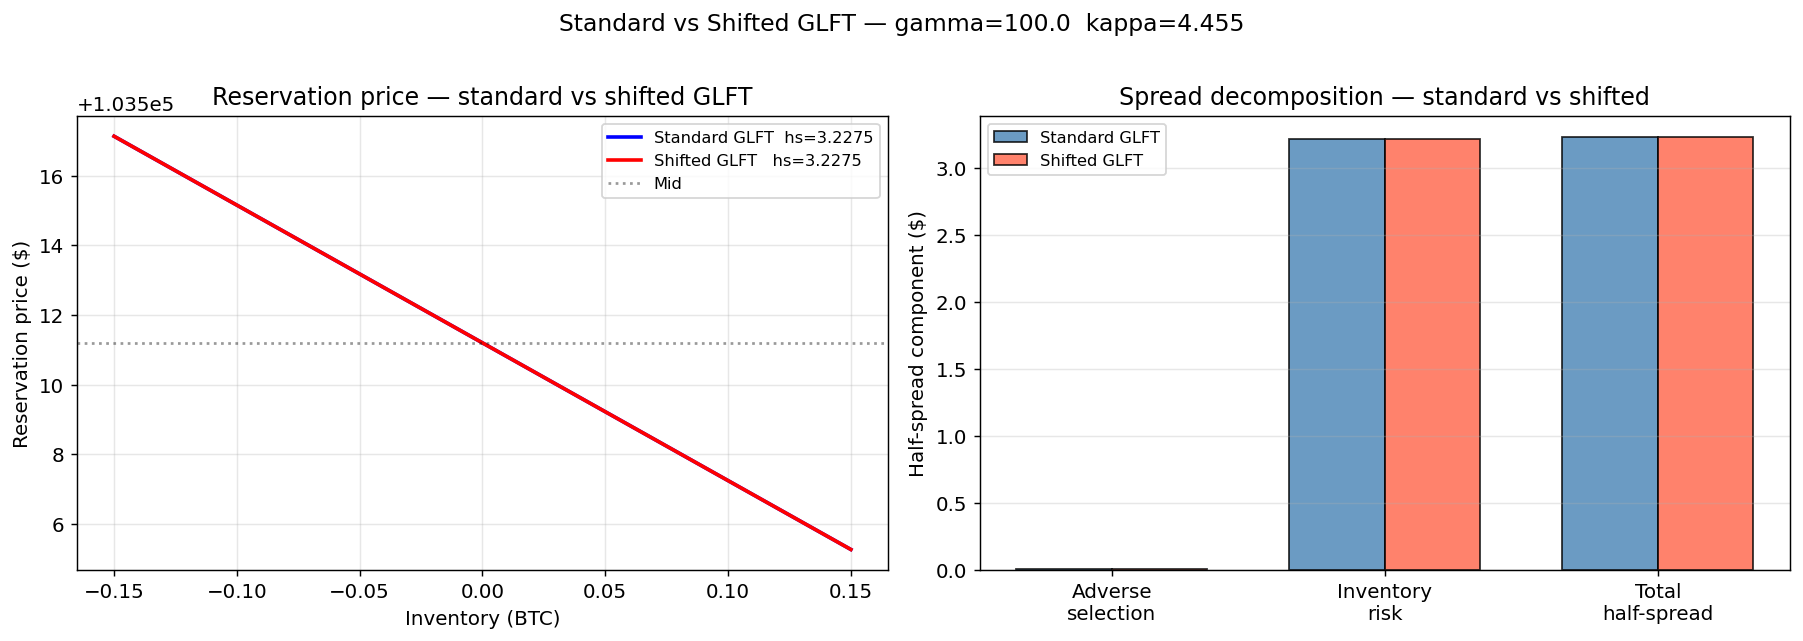

ShiftedGLFT — mid=103511.20  inv=0.0500
  A_liq=4.9305  A_mom=0.1503  A_total=5.0808  kappa=4.4550  gamma=100.0000
  mom_fraction=0.030  (=3.0% of fills inevitably adverse)
  reservation=103509.2214  (skew=+1.9786)
  half_spread=3.2275  (0.6236 bps)
    adverse=0.009784  inv=3.217722
  bid=103505.9939  ask=103512.4489


In [22]:
# Inventory skew comparison plot
inv_range = np.linspace(-0.15, 0.15, 61)

res_std = [strat_std.reservation_price(mid_price, q, sigma_est, A_liq_use+A_mom_use) for q in inv_range]
res_sh  = [strat_sh.reservation_price(mid_price, q, sigma_est) for q in inv_range]
hs_std, adv_std, inv_std = strat_std.optimal_half_spread(sigma_est, mid_price, A_liq_use+A_mom_use)
hs_sh,  adv_sh,  inv_sh  = strat_sh.optimal_half_spread(sigma_est, mid_price)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(inv_range, res_std, 'b-', lw=2, label=f'Standard GLFT  hs={hs_std:.4f}')
axes[0].plot(inv_range, res_sh,  'r-', lw=2, label=f'Shifted GLFT   hs={hs_sh:.4f}')
axes[0].axhline(mid_price, color='black', ls=':', alpha=0.4, label='Mid')
axes[0].set_xlabel('Inventory (BTC)')
axes[0].set_ylabel('Reservation price ($)')
axes[0].set_title('Reservation price — standard vs shifted GLFT')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Spread decomposition
labels  = ['Adverse\nselection', 'Inventory\nrisk', 'Total\nhalf-spread']
std_vals = [adv_std, inv_std, hs_std]
sh_vals  = [adv_sh,  inv_sh,  hs_sh]
x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, std_vals, w, label='Standard GLFT', color='steelblue', alpha=0.8, edgecolor='black')
axes[1].bar(x + w/2, sh_vals,  w, label='Shifted GLFT',  color='tomato',    alpha=0.8, edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Half-spread component ($)')
axes[1].set_title('Spread decomposition — standard vs shifted')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle(f'Standard vs Shifted GLFT — gamma={gamma}  kappa={kappa_use:.3f}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../analysis/glft_comparison_{DATE}.png', dpi=150, bbox_inches='tight')
plt.show()

print(strat_sh.describe(type('S', (), {'mid_price': mid_price, 'sigma': sigma_est,
                                        'kappa': strat_sh.A_total, 'ofi': 0.0,
                                        'spread': 0.01, 'momentum': 0.0,
                                        'momentum_raw': 0.0, 'lambda_buy': 0.0,
                                        'lambda_sell': 0.0})(), inventory=0.05))

## 5. Summary

In [23]:
print('=' * 65)
print('SHIFTED EXPONENTIAL MODEL SUMMARY')
print('=' * 65)
print(f'Date: {DATE}')
print()
print('Full-day (Approach B):')
print(f'  Pure exp:    kappa={exp_r["kappa"]:.4f}  R2={exp_r["r2"]:.4f}  AIC={exp_r["aic"]:.2f}')
print(f'  Shifted:     kappa={sh_r["kappa"]:.4f}  A_liq={sh_r["A_liq"]:.4f}  '
      f'A_mom={sh_r["A_floor"]:.4f}  R2={sh_r["r2"]:.4f}  AIC={sh_r["aic"]:.2f}')
print(f'  Delta AIC:   {comp["delta_aic"]:+.2f}  preferred={comp["preferred"]}')
print(f'  Mom fraction: {sh_r["mom_fraction"]*100:.1f}% of fills inevitably adverse')
print()
print('Rolling windows:')
print(f'  Shifted preferred in {(rsh["preferred"]=="shifted").mean()*100:.0f}% of windows')
print(f'  Mom fraction mean={rsh["mom_frac"].mean()*100:.1f}%  std={rsh["mom_frac"].std()*100:.1f}%')
print()
if len(good_sh) > 0:
    print('High-quality shifted windows (R2>0.8):')
    print(f'  Count:    {len(good_sh)}/{len(rsh)}')
    print(f'  kappa:    {good_sh["kappa_sh"].mean():.4f} +- {good_sh["kappa_sh"].std():.4f}')
    print(f'  A_liq:    {good_sh["A_liq"].mean():.4f} +- {good_sh["A_liq"].std():.4f}')
    print(f'  A_mom:    {good_sh["A_mom"].mean():.4f} +- {good_sh["A_mom"].std():.4f}')
    print(f'  mom_frac: {good_sh["mom_frac"].mean()*100:.1f}%')
    print()
    print('Recommended config for ShiftedGLFTMarketMaker:')
    print(f'  kappa = {good_sh["kappa_sh"].mean():.4f}')
    print(f'  A_liq = {good_sh["A_liq"].mean():.4f}')
    print(f'  A_mom = {good_sh["A_mom"].mean():.4f}')

SHIFTED EXPONENTIAL MODEL SUMMARY
Date: 2025-05-13

Full-day (Approach B):
  Pure exp:    kappa=0.3113  R2=0.4637  AIC=-38.64
  Shifted:     kappa=4.4502  A_liq=5.0000  A_mom=0.1512  R2=0.9999  AIC=-128.50
  Delta AIC:   +89.86  preferred=shifted
  Mom fraction: 2.9% of fills inevitably adverse

Rolling windows:
  Shifted preferred in 100% of windows
  Mom fraction mean=3.0%  std=1.7%

High-quality shifted windows (R2>0.8):
  Count:    276/276
  kappa:    4.4550 +- 0.2787
  A_liq:    4.9305 +- 0.3162
  A_mom:    0.1503 +- 0.0746
  mom_frac: 3.0%

Recommended config for ShiftedGLFTMarketMaker:
  kappa = 4.4550
  A_liq = 4.9305
  A_mom = 0.1503


In [24]:
A_liq, kappa, A_floor, se_A_liq, se_kappa, se_A_floor, r2 = fit_shifted_exponential(fp_B)

print(f'A_liq  = {A_liq:.4f}  SE={se_A_liq:.4f}  CV={se_A_liq/A_liq:.2f}')
print(f'kappa  = {kappa:.4f}  SE={se_kappa:.4f}  CV={se_kappa/kappa:.2f}')
print(f'A_floor= {A_floor:.4f}  SE={se_A_floor:.4f}  CV={se_A_floor/A_floor:.2f}')

A_liq  = 5.0000  SE=0.6025  CV=0.12
kappa  = 4.4502  SE=0.2415  CV=0.05
A_floor= 0.1512  SE=0.0005  CV=0.00
